<a href="https://colab.research.google.com/github/Rudra30/Bank_Atm/blob/master/Stack_Overflow_Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Stack_Overflow.csv to Stack_Overflow.csv


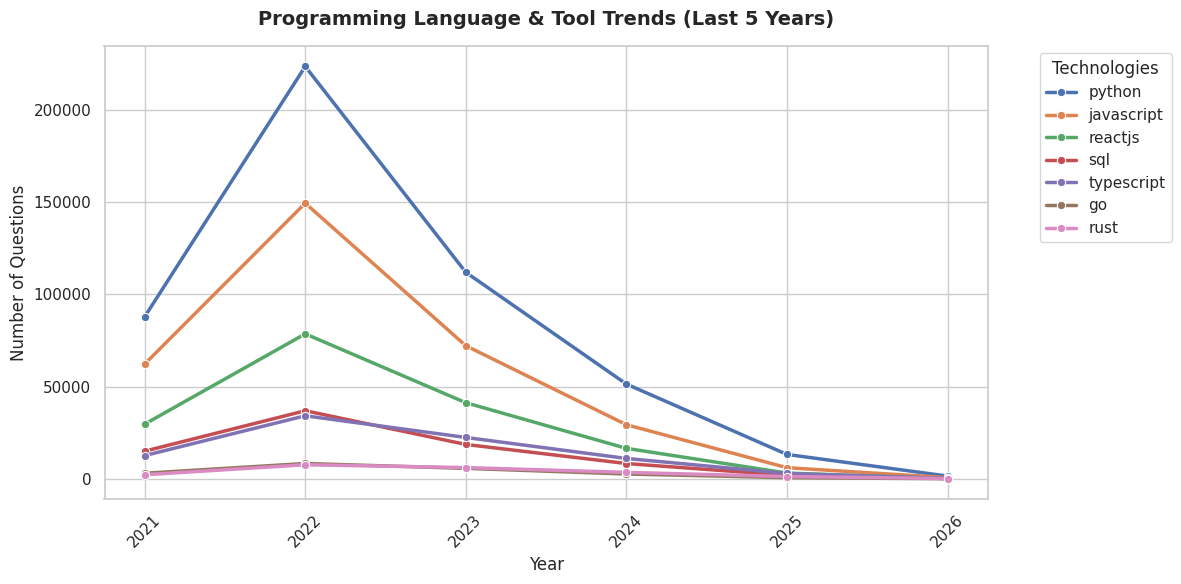

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Upload CSV file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Read CSV
df = pd.read_csv(file_name)

# 3. Identify column names automatically
time_col = 'Month' if 'Month' in df.columns else 'Year'
value_col = 'PercentageShare' if 'PercentageShare' in df.columns else 'QuestionCount'

# Proper Date Sorting
if time_col == 'Month':
    df['Month'] = pd.to_datetime(df['Month'])

# 4. Plot Design
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 5. Plotting trend lines
sns.lineplot(
    data=df,
    x=time_col,
    y=value_col,
    hue='TagName',
    marker='o' if time_col == 'Year' else None,
    linewidth=2.5
)

# 6. Customization
plt.title('Programming Language & Tool Trends (Last 5 Years)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(time_col, fontsize=12)
plt.ylabel('Market Share (%)' if value_col == 'PercentageShare' else 'Number of Questions', fontsize=12)
plt.legend(title='Technologies', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [2]:
import plotly.express as px

# Interactive line chart
fig = px.line(
    df,
    x=time_col,
    y=value_col,
    color='TagName',
    markers=True,
    title='Interactive Technology Popularity Shift',
    labels={value_col: 'Volume / Share', time_col: 'Time Period', 'TagName': 'Tool'}
)

fig.update_layout(template='plotly_white', hovermode='x unified')
fig.show()

In [3]:
import pandas as pd

# 1. Detect time and value columns automatically
time_col = 'Month' if 'Month' in df.columns else 'Year'
value_col = 'PercentageShare' if 'PercentageShare' in df.columns else 'QuestionCount'

if time_col == 'Month':
    df[time_col] = pd.to_datetime(df[time_col])

df_sorted = df.sort_values(by=[time_col])

# 2. Compute key growth metrics per tool
metrics = []
for tag, group in df_sorted.groupby('TagName'):
    start_val = group[value_col].iloc[0]
    end_val = group[value_col].iloc[-1]
    peak_val = group[value_col].max()

    # Calculate percentage changes
    growth_pct = ((end_val - start_val) / start_val) * 100 if start_val > 0 else 0
    drop_from_peak_pct = ((end_val - peak_val) / peak_val) * 100 if peak_val > 0 else 0

    # Categorize overall performance
    if growth_pct >= 20 and drop_from_peak_pct >= -15:
        category = '🚀 Growth Leader'
    elif growth_pct <= -15 or drop_from_peak_pct <= -30:
        category = '📉 Declining Tool'
    else:
        category = '📉 Seasonal / Post-Peak Drop'

    metrics.append({
        'Technology': tag,
        'Start Value': round(start_val, 2),
        'Latest Value': round(end_val, 2),
        'Peak Value': round(peak_val, 2),
        'Overall Growth (%)': round(growth_pct, 2),
        'Drop from Peak (%)': round(drop_from_peak_pct, 2),
        'Classification': category
    })

# 3. Summary DataFrame
metrics_df = pd.DataFrame(metrics).sort_values(by='Overall Growth (%)', ascending=False).reset_index(drop=True)

# 4. Render styled interactive table in Colab
metrics_df.style.background_gradient(subset=['Overall Growth (%)', 'Drop from Peak (%)'], cmap='RdYlGn')

,Technology,Start Value,Latest Value,Peak Value,Overall Growth (%),Drop from Peak (%),Classification
0,rust,2205,162,7617,-92.650000,-97.870000,📉 Declining Tool
1,typescript,12596,245,34160,-98.050000,-99.280000,📉 Declining Tool
2,go,3023,56,8312,-98.150000,-99.330000,📉 Declining Tool
3,python,87788,1474,223471,-98.320000,-99.340000,📉 Declining Tool
4,sql,14986,207,36900,-98.620000,-99.440000,📉 Declining Tool
5,javascript,62193,636,149366,-98.980000,-99.570000,📉 Declining Tool
6,reactjs,29639,115,78562,-99.610000,-99.850000,📉 Declining Tool
